# Simple Linear Regression

This notebook covers simple (single-feature) linear regression: fitting a line to data with `scikit-learn`, interpreting the slope and intercept, and evaluating the fit with regression metrics.

**What is Simple Linear Regression?**
- Models the relationship between **one input feature** and a continuous target as a straight line: `y = mx + b`
- `m` (slope / coefficient) tells you how much `y` changes per unit change in `x`
- `b` (intercept) is the predicted `y` when `x = 0`
- Fit by minimizing the sum of squared errors between predictions and actual values (Ordinary Least Squares)

## 0. Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## 1. Load and Explore the Data

`placement.csv` has two columns: `cgpa` (a student's CGPA) and `package` (their placement package in LPA). The goal is to predict `package` from `cgpa`.

In [2]:
df = pd.read_csv('placement.csv')
df.head()

,cgpa,package
0,6.48,2.37
1,6.84,2.79
2,4.76,1.72
3,8.54,4.32
4,5.11,2.22


In [3]:
df.shape

(200, 2)

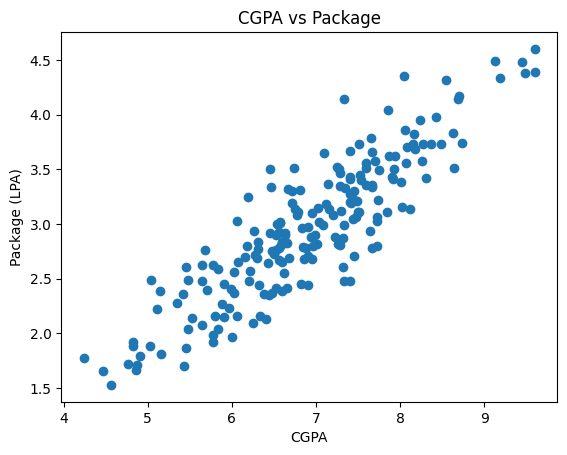

In [4]:
plt.scatter(df['cgpa'], df['package'])
plt.xlabel('CGPA')
plt.ylabel('Package (LPA)')
plt.title('CGPA vs Package')
plt.show()

## 2. Train / Test Split

Keep a portion of the data unseen so we can check how well the model generalizes.

In [5]:
X = df.iloc[:, 0:1]   # keep as DataFrame (2D) — sklearn expects 2D input
y = df.iloc[:, -1]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)
X_train.shape, X_test.shape

((160, 1), (40, 1))

## 3. Fit the Model

All scikit-learn estimators follow the same pattern: create → `fit()` → `predict()`.

In [6]:
lr = LinearRegression()
lr.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [7]:
m = lr.coef_[0]
b = lr.intercept_
print(f"Slope (m): {m:.4f}")
print(f"Intercept (b): {b:.4f}")

Slope (m): 0.5338
Intercept (b): -0.7170


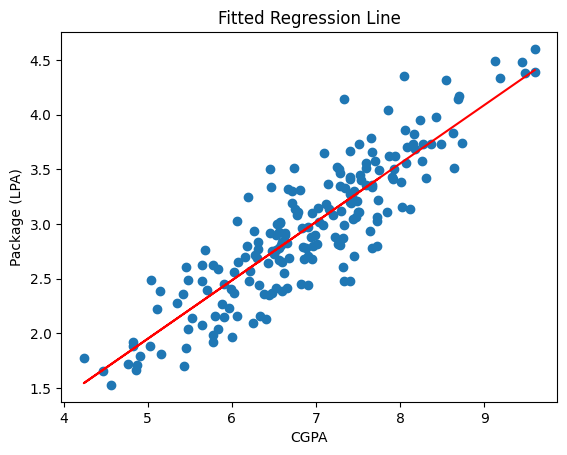

In [8]:
# Visualize the fitted line against the training data
plt.scatter(df['cgpa'], df['package'])
plt.plot(X_train, lr.predict(X_train), color='red')
plt.xlabel('CGPA')
plt.ylabel('Package (LPA)')
plt.title('Fitted Regression Line')
plt.show()

## 4. Predict

Predict the package for a new CGPA value, and confirm it matches the manual `y = mx + b` calculation.

In [9]:
lr.predict(X_test.iloc[0].values.reshape(1,1))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([2.48556257])

In [10]:
# Sanity check: same result using the raw slope/intercept formula
cgpa_value = X_test.iloc[0].values[0]
m * cgpa_value + b

np.float64(2.4855625717359886)

## 5. Regression Metrics

`.score()` gives R² directly, but for a fuller picture use these four metrics together.

| Metric | What it measures |
|---|---|
| MAE (Mean Absolute Error) | Average absolute difference between prediction and actual — same units as `y`, easy to interpret |
| MSE (Mean Squared Error) | Average squared difference — penalizes large errors more heavily |
| RMSE (Root MSE) | Square root of MSE — back in the same units as `y` |
| R² (R-squared) | Fraction of variance in `y` explained by the model (1.0 = perfect, 0 = no better than predicting the mean) |

In [11]:
y_pred = lr.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MAE:  {mae:.4f}")
print(f"MSE:  {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R2:   {r2:.4f}")

MAE:  0.2497
MSE:  0.0986
RMSE: 0.3139
R2:   0.7186


### Adjusted R²

Plain R² always increases (or stays the same) when you add more features — even useless ones — because the model gets more freedom to fit noise. **Adjusted R²** corrects for this by penalizing extra features, so it only increases if the new feature genuinely improves the fit. It's the right metric to use when comparing models with different numbers of features (see the multiple linear regression notebook).

$$\text{Adjusted } R^2 = 1 - \frac{(1 - R^2)(n - 1)}{n - k - 1}$$

where `n` = number of samples and `k` = number of features.

In [12]:
n = X_test.shape[0]
k = X_test.shape[1]  # 1 feature here

adjusted_r2 = 1 - ((1 - r2) * (n - 1) / (n - k - 1))
print(f"Adjusted R2: {adjusted_r2:.4f}")

Adjusted R2: 0.7112


---
## Simple Linear Regression Cheat Sheet

Quick reference for the patterns shown above.

### Fitting & Predicting
| Code | Description |
|---|---|
| `LinearRegression()` | Create an OLS linear regression estimator |
| `lr.fit(X_train, y_train)` | Fit the model — `X_train` must be 2D |
| `lr.predict(X_test)` | Predict target values for new inputs |
| `lr.coef_` | Learned slope(s) — one per feature |
| `lr.intercept_` | Learned intercept (`b`) |

### Metrics
| Code | Description |
|---|---|
| `mean_absolute_error(y_test, y_pred)` | MAE |
| `mean_squared_error(y_test, y_pred)` | MSE |
| `np.sqrt(mean_squared_error(y_test, y_pred))` | RMSE |
| `r2_score(y_test, y_pred)` | R² |
| `1 - ((1-r2)*(n-1)/(n-k-1))` | Adjusted R² (manual — sklearn has no built-in) |

### Gotchas
- `X` must be 2D even for a single feature — use `df.iloc[:, 0:1]`, not `df.iloc[:, 0]`
- R² alone can mislead when comparing models with different feature counts — use adjusted R² instead
- Always evaluate on the **test** set, never the training set